# BÀI THỰC HÀNH 1: XÂY DỰNG MẠNG NEURON ĐƠN GIẢN

In [1]:
from keras.datasets import mnist

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

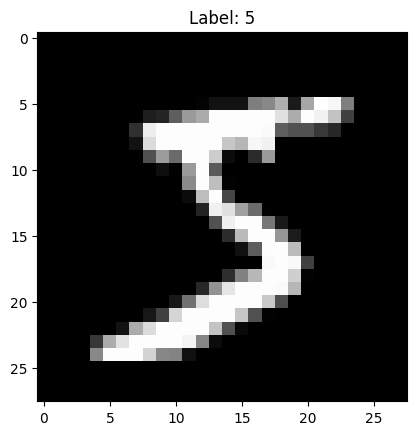

In [3]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [4]:
print("Kích thước 2 tập dữ liệu:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

Kích thước 2 tập dữ liệu:
X_train: (60000, 28, 28)
X_test: (10000, 28, 28)


In [5]:
print("Số lượng mỗi lớp trong tập train:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Lớp {label}: {count} mẫu")

print("Số lượng mỗi lớp trong tập test:")
unique, counts = np.unique(y_test, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Lớp {label}: {count} mẫu")


Số lượng mỗi lớp trong tập train:
Lớp 0: 5923 mẫu
Lớp 1: 6742 mẫu
Lớp 2: 5958 mẫu
Lớp 3: 6131 mẫu
Lớp 4: 5842 mẫu
Lớp 5: 5421 mẫu
Lớp 6: 5918 mẫu
Lớp 7: 6265 mẫu
Lớp 8: 5851 mẫu
Lớp 9: 5949 mẫu
Số lượng mỗi lớp trong tập test:
Lớp 0: 980 mẫu
Lớp 1: 1135 mẫu
Lớp 2: 1032 mẫu
Lớp 3: 1010 mẫu
Lớp 4: 982 mẫu
Lớp 5: 892 mẫu
Lớp 6: 958 mẫu
Lớp 7: 1028 mẫu
Lớp 8: 974 mẫu
Lớp 9: 1009 mẫu


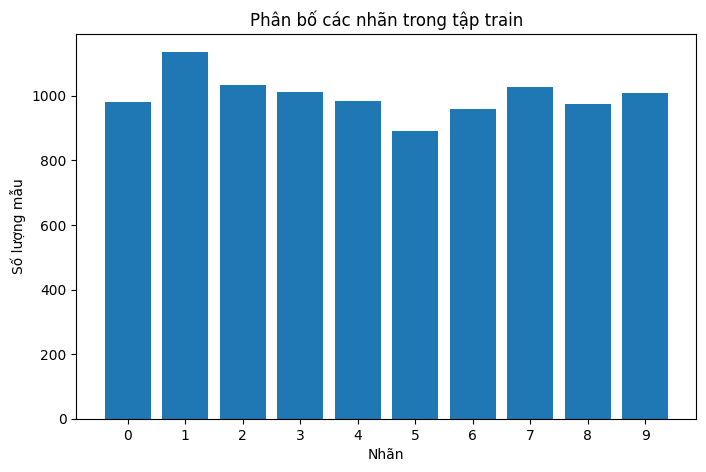

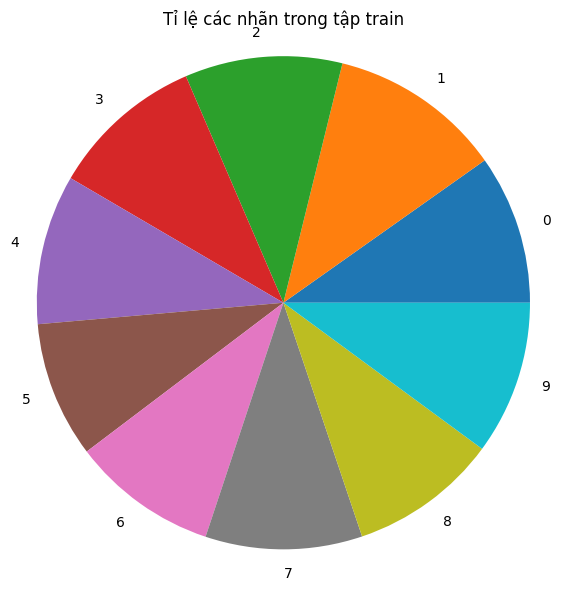

In [6]:
# Biểu đồ cột thể hiện sự phân bố các nhãn trong tập train
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, tick_label=unique)
plt.xlabel('Nhãn')
plt.ylabel('Số lượng mẫu')
plt.title('Phân bố các nhãn trong tập train')
plt.show()

# Biểu đồ tròn thể hiện tỉ lệ các nhãn trong tập train
plt.figure(figsize=(7, 7))
plt.pie(counts, labels=unique)
plt.title('Tỉ lệ các nhãn trong tập train')
plt.axis('equal')
plt.show()


### Bài 1: Xây dựng mô hình 1-layer MLP và hàm Softmax làm activation function. Huấn luyện mô hình này sử dụng SGD làm optimizer và đánh giá trên các độ đo accuracy, precision, recall và F1-macro. Đánh giá kết quả của mô hình với từng chữ số.

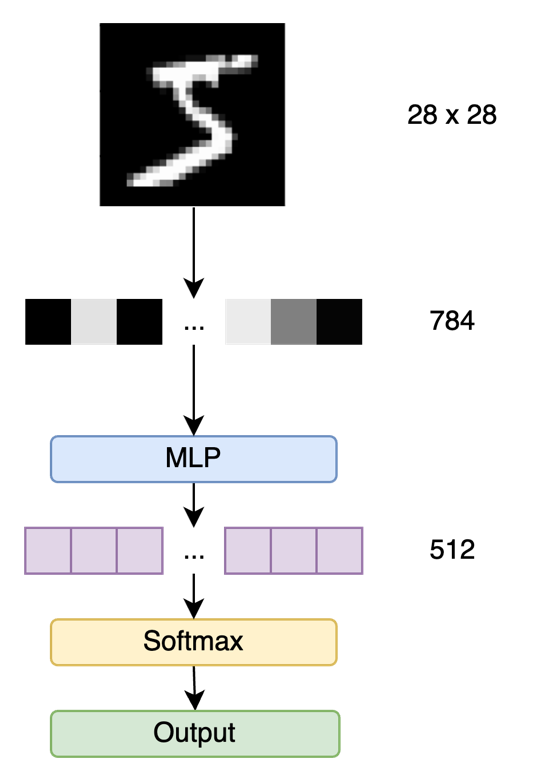

In [16]:
def train_model(model, train_loader, num_epochs, criterion, optimizer):
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        y_pred = torch.argmax(torch.softmax(outputs, dim=1), dim=1).cpu().numpy()
        
    if torch.is_tensor(y_test):
        y_true = y_test.cpu().numpy()
    else:
        y_true = y_test

    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average='macro', zero_division=0)
    }
    print("Accuracy:", results["accuracy"])
    print("Precision (macro):", results["precision_macro"])
    print("Recall (macro):", results["recall_macro"])
    print("F1-score (macro):", results["f1_macro"])
    
    print(classification_report(y_test, y_pred, digits=4))


In [8]:
class MLP1Layer(nn.Module):
    def __init__(self, input_dim=28*28, num_classes=10):
        super(MLP1Layer, self).__init__()
        self.fc = nn.Linear(input_dim, num_classes)# Không cần softmax vì CrossEntropyLoss đã bao gồm softmax bên trong
    def forward(self, x):
        return self.fc(x)

In [9]:
X_train = torch.from_numpy(X_train.reshape(X_train.shape[0], -1)).float()
X_test = torch.from_numpy(X_test.reshape(X_test.shape[0], -1)).float()

In [10]:
model_1_layer = MLP1Layer()

criterion1 = nn.CrossEntropyLoss()
optimizer1 = torch.optim.SGD(model_1_layer.parameters(), lr=0.001)


num_epochs = 10
batch_size = 256

train_dataset = torch.utils.data.TensorDataset(X_train, torch.tensor(y_train, dtype=torch.long))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [11]:
train_model(model_1_layer, train_loader, num_epochs, criterion1, optimizer1)

Epoch [1/10], Loss: 27.1324
Epoch [2/10], Loss: 13.0113
Epoch [3/10], Loss: 13.2167
Epoch [4/10], Loss: 11.5494
Epoch [5/10], Loss: 11.4807
Epoch [6/10], Loss: 11.4005
Epoch [7/10], Loss: 10.0954
Epoch [8/10], Loss: 10.7737
Epoch [9/10], Loss: 10.5690
Epoch [10/10], Loss: 10.6403


In [17]:
evaluate_model(model_1_layer, X_test, y_test)

Accuracy: 0.9135
Precision (macro): 0.9134136757180528
Recall (macro): 0.9122093188473585
F1-score (macro): 0.91243248043862
              precision    recall  f1-score   support

           0     0.9711    0.9602    0.9656       980
           1     0.9709    0.9692    0.9700      1135
           2     0.9222    0.8953    0.9086      1032
           3     0.8690    0.9198    0.8937      1010
           4     0.9546    0.8778    0.9146       982
           5     0.8803    0.8655    0.8728       892
           6     0.9251    0.9415    0.9333       958
           7     0.9020    0.9309    0.9162      1028
           8     0.8741    0.8480    0.8609       974
           9     0.8649    0.9138    0.8887      1009

    accuracy                         0.9135     10000
   macro avg     0.9134    0.9122    0.9124     10000
weighted avg     0.9143    0.9135    0.9135     10000



### Bài 2: Xây dựng mô hình 3-layer MLP, hàm ReLU và hàm softmax làm activation function. Trong đó activation function cho 2 layer đầu là ReLU và activation function cho layer cuối là Softmax. Huấn luyện mô hình này sử dụng SGD làm optimizer và đánh giá trên các độ đo accuracy, precision, recall và F1-macro. Đánh giá kết quả của mô hình với từng chữ số.

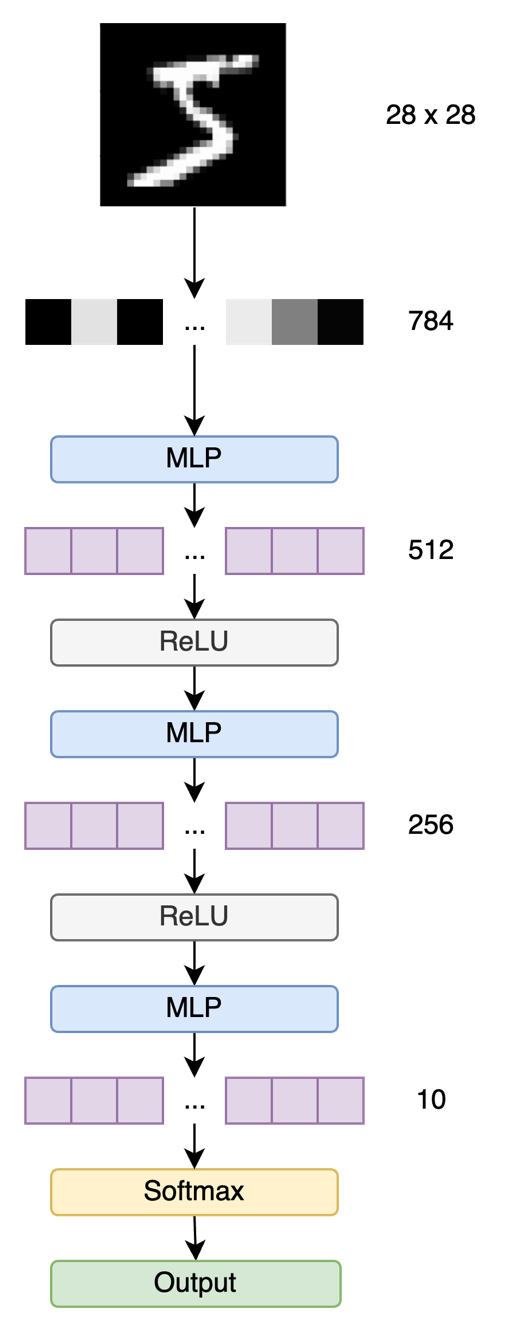

In [13]:
class MLP3Layer(nn.Module):
    def __init__(self, input_dim=28*28, hidden1=512, hidden2=256, num_classes=10):
        super(MLP3Layer, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes)
            # Không cần softmax vì CrossEntropyLoss đã có softmax bên trong
        )
    
    def forward(self, x):
        return self.model(x)

In [14]:
model_3_layer = MLP3Layer()
criterion3 = nn.CrossEntropyLoss()
optimizer3 = torch.optim.SGD(model_3_layer.parameters(), lr=0.001)

num_epochs = 10
train_model(model_3_layer, train_loader, num_epochs, criterion3, optimizer3)

Epoch [1/10], Loss: 0.7391
Epoch [2/10], Loss: 0.2662
Epoch [3/10], Loss: 0.2017
Epoch [4/10], Loss: 0.1661
Epoch [5/10], Loss: 0.1422
Epoch [6/10], Loss: 0.1240
Epoch [7/10], Loss: 0.1105
Epoch [8/10], Loss: 0.0998
Epoch [9/10], Loss: 0.0900
Epoch [10/10], Loss: 0.0824


In [18]:
evaluate_model(model_3_layer, X_test, y_test)

Accuracy: 0.9594
Precision (macro): 0.9588914154078585
Recall (macro): 0.9588444688804569
F1-score (macro): 0.9588516736026049
              precision    recall  f1-score   support

           0     0.9668    0.9806    0.9737       980
           1     0.9842    0.9877    0.9859      1135
           2     0.9715    0.9564    0.9639      1032
           3     0.9553    0.9525    0.9539      1010
           4     0.9620    0.9542    0.9581       982
           5     0.9458    0.9383    0.9420       892
           6     0.9626    0.9666    0.9646       958
           7     0.9592    0.9601    0.9596      1028
           8     0.9398    0.9456    0.9427       974
           9     0.9418    0.9465    0.9441      1009

    accuracy                         0.9594     10000
   macro avg     0.9589    0.9588    0.9589     10000
weighted avg     0.9594    0.9594    0.9594     10000

